In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [10]:
import pandas as pd
df = pd.read_csv('C_0_z.csv', sep=',')

In [17]:
z_values = np.array(df['z'])
Co_values = np.array(df['C_0'])

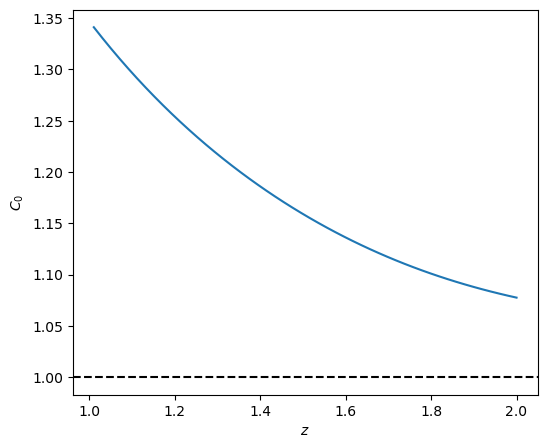

In [23]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[z_values>1], Co_values[z_values>1])
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

In [24]:
alpha, beta, F0 = 3, 3, 0.1

In [47]:
def f(D, z):
    exponent = D**(-2*alpha)/(2*alpha**2*F0**2/z)
    return np.exp(-exponent)

In [35]:
Delta_array = np.linspace(0.01, 1, 200)

In [49]:
def I1_integral(z):
    I1 = np.trapz((Delta_array-1)*f(Delta_array, z)/Delta_array**beta, Delta_array)
    return I1

In [50]:
def C0(z):
    factor = -18*F0**2/z
    ln_int = np.log(-2*I1_integral(z))
    
    return np.sqrt(factor*ln_int)

In [67]:
C0_approx = np.zeros_like(z_values[1:])

for idx, z in enumerate(z_values[1:]):
    C0_approx[idx] = C0(z)

In [68]:
C0_approx

array([3.89551423, 3.32148269, 2.99437034, 2.77510049, 2.61418131,
       2.48918544, 2.38824375, 2.30438637, 2.23320427, 2.17174804,
       2.11795675, 2.07033911, 2.02778466, 1.98944644, 1.95466526,
       1.922919  , 1.89378784, 1.86692967, 1.84206242, 1.81895111,
       1.79739811, 1.77723581, 1.75832097, 1.74053031, 1.72375708,
       1.70790826, 1.6929024 , 1.67866779, 1.66514103, 1.6522658 ,
       1.63999191, 1.62827441, 1.61707296, 1.6063512 , 1.59607627,
       1.58621837, 1.57675045, 1.56764782, 1.55888795, 1.55045021,
       1.54231565, 1.53446688, 1.52688785, 1.51956374, 1.51248086,
       1.50562652, 1.49898895, 1.4925572 , 1.48632109, 1.48027113,
       1.47439844, 1.46869475, 1.4631523 , 1.45776382, 1.4525225 ,
       1.44742193, 1.44245609, 1.43761931, 1.43290625, 1.42831188,
       1.42383143, 1.41946042, 1.41519458, 1.4110299 , 1.40696255,
       1.40298893, 1.3991056 , 1.3953093 , 1.39159693, 1.38796554,
       1.38441233, 1.38093463, 1.37752989, 1.37419568, 1.37092

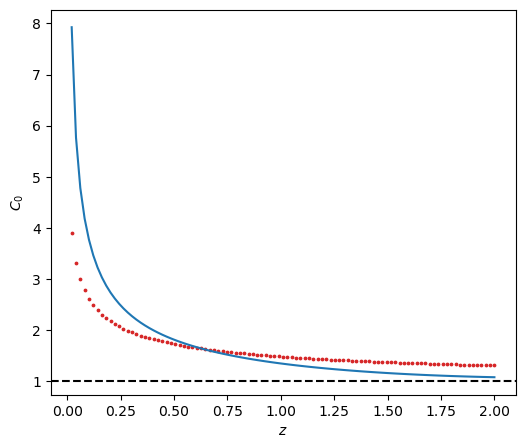

In [76]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], Co_values[1:])
ax.scatter(z_values[1:], C0_approx, c='tab:red', s=3)
ax.axhline(y=1, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$C_{0}$")

plt.show()

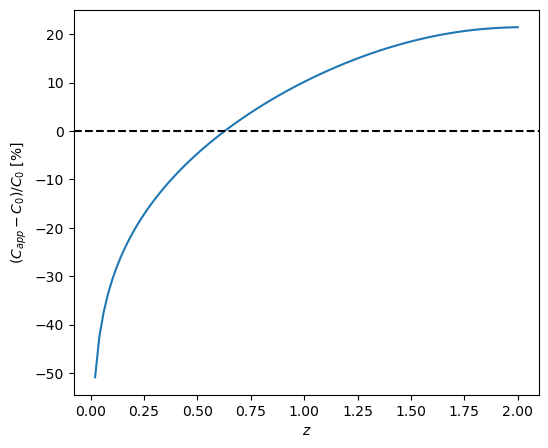

In [78]:
fig= plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)

ax.plot(z_values[1:], (C0_approx-Co_values[1:])/Co_values[1:]*100)

ax.axhline(y=0, ls='--', c='black')

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$(C_{app}-C_{0})/C_0$ [%]")

plt.show()